# Data

## Read data

In [18]:
import pandas as pd
pd.set_option('display.max_rows', None)
df = pd.read_csv('Bird_strikes.csv')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25429 entries, 0 to 25428
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   RecordID                  25429 non-null  int64  
 1   AircraftType              25429 non-null  str    
 2   AirportName               25429 non-null  str    
 3   AltitudeBin               25429 non-null  str    
 4   MakeModel                 25429 non-null  str    
 5   NumberStruck              25429 non-null  str    
 6   NumberStruckActual        25429 non-null  int64  
 7   Effect                    2078 non-null   str    
 8   FlightDate                25429 non-null  str    
 9   Damage                    25429 non-null  str    
 10  Engines                   25195 non-null  float64
 11  Operator                  25429 non-null  str    
 12  OriginState               24980 non-null  str    
 13  FlightPhase               25429 non-null  str    
 14  ConditionsPrecipi

## Check for missing data

In [19]:
percent_missing = df.isnull().sum() * 100 / len(df)
percent_missing.sort_values(ascending=False, inplace=True)
print(percent_missing)

ConditionsPrecipitation     92.075976
Effect                      91.828228
Remarks                     18.722718
OriginState                  1.765701
Engines                      0.920209
AltitudeBin                  0.000000
AircraftType                 0.000000
AirportName                  0.000000
MakeModel                    0.000000
RecordID                     0.000000
Damage                       0.000000
FlightDate                   0.000000
NumberStruckActual           0.000000
NumberStruck                 0.000000
FlightPhase                  0.000000
Operator                     0.000000
RemainsCollected?            0.000000
RemainsSentToSmithsonian     0.000000
WildlifeSize                 0.000000
ConditionsSky                0.000000
WildlifeSpecies              0.000000
PilotWarned                  0.000000
Cost                         0.000000
Altitude                     0.000000
PeopleInjured                0.000000
IsAircraftLarge?             0.000000
dtype: float

## Data cleaning

In [20]:
cols_to_drop = []

for column in df.columns:
    if percent_missing[column] > 50:
        cols_to_drop.append(column)

df.drop(columns=cols_to_drop, inplace=True)

# Data manipulation
df['FlightDate'] = pd.to_datetime(df['FlightDate'], format="%m/%d/%y %H:%M")
df['Year'] = df['FlightDate'].dt.year
df['Month'] = df['FlightDate'].dt.month
df['IsAircraftLarge?'] = df['IsAircraftLarge?'] == 'Yes'
df['Damage'] = df['Damage'] == 'Caused damage'
df['Engines'] = df['Engines'].fillna(df['Engines'].mode().iloc[0]) #Fill with most common value

columns_to_keep = ["AirportName", "NumberStruckActual", "Month", "Year", "Engines", "FlightPhase", "WildlifeSize", "ConditionsSky", "WildlifeSpecies", "Altitude", "IsAircraftLarge?", "Damage"]

df = df[columns_to_keep]

df.sort_values(by='AirportName', inplace=True)

df.head(10)

,AirportName,NumberStruckActual,Month,Year,Engines,FlightPhase,WildlifeSize,ConditionsSky,WildlifeSpecies,Altitude,IsAircraftLarge?,Damage
23056,ABERDEEN REGIONAL AR,1,1,2011,2.0,Take-off run,Small,No Cloud,Unknown bird - small,0,False,False
7649,ABERDEEN REGIONAL AR,1,9,2002,2.0,Climb,Medium,No Cloud,Swainson's hawk,300,False,False
8223,ABERDEEN REGIONAL AR,1,4,2003,2.0,Landing Roll,Medium,No Cloud,Ring-necked pheasant,0,False,False
8656,ABERDEEN REGIONAL AR,1,7,2003,2.0,Landing Roll,Small,No Cloud,Upland sandpiper,0,False,False
11485,ABERDEEN REGIONAL AR,1,8,2005,2.0,Landing Roll,Small,Some Cloud,Unknown bird - small,0,False,False
24174,ABERDEEN REGIONAL AR,1,7,2011,2.0,Landing Roll,Small,Some Cloud,American kestrel,0,False,False
2331,ABERDEEN REGIONAL AR,8,10,2007,2.0,Approach,Large,No Cloud,Unknown bird - large,1500,False,False
15624,ABERDEEN REGIONAL AR,1,10,2007,2.0,Approach,Small,Overcast,Blackbirds,600,False,False
17399,ABERDEEN REGIONAL AR,1,10,2008,2.0,Climb,Medium,Overcast,Ring-billed gull,200,False,False
23,ABERDEEN REGIONAL AR,8,3,2000,2.0,Climb,Small,Some Cloud,Unknown bird - small,2000,False,False


# Classification

In [21]:
from catboost import CatBoostClassifier

y = df['Damage']
X = df.drop(columns='Damage')

SEED = 1


## Split train data and validation parts

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.25, random_state=SEED, stratify=y)

## Training time!

## Basic working model

In [23]:
cat_features = [
    'AirportName', 
    'FlightPhase', 
    'WildlifeSize', 
    'ConditionsSky', 
    'WildlifeSpecies'
]

params = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'verbose': 200,
    'cat_features': cat_features,
    'task_type': 'GPU',
    'random_seed': SEED
}
cbc_1 = CatBoostClassifier(**params)
cbc_1.fit(X_train, y_train, 
          eval_set=(X_valid, y_valid), 
          use_best_model=True,
          plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Learning rate set to 0.055423
0:	test: 0.8012609	best: 0.8012609 (0)	total: 83.6ms	remaining: 1m 23s


Default metric period is 5 because AUC is/are not implemented for GPU


200:	test: 0.8584470	best: 0.8584470 (200)	total: 14.3s	remaining: 56.7s
400:	test: 0.8590892	best: 0.8593024 (395)	total: 25.7s	remaining: 38.4s
600:	test: 0.8594884	best: 0.8597459 (520)	total: 39.1s	remaining: 26s
800:	test: 0.8591323	best: 0.8597459 (520)	total: 51.3s	remaining: 12.7s
999:	test: 0.8590676	best: 0.8597459 (520)	total: 1m 2s	remaining: 0us
bestTest = 0.8597458899
bestIteration = 520
Shrink model to first 521 iterations.


CatBoostClassifier(cat_features=['AirportName', 'FlightPhase', 'WildlifeSize', 'ConditionsSky', 'WildlifeSpecies'], eval_metric='AUC', loss_function='Logloss', random_seed=1, task_type='GPU', verbose=200)

In [24]:
cbc_1.get_feature_importance(prettified=True)

,Feature Id,Importances
0,WildlifeSpecies,19.159325
1,WildlifeSize,18.919793
2,Altitude,11.299309
3,AirportName,10.833986
4,FlightPhase,10.622647
5,NumberStruckActual,9.031643
6,ConditionsSky,5.090142
7,Year,4.960378
8,Month,4.166352
9,IsAircraftLarge?,3.198603


## Cross-validation

In [25]:
from catboost import Pool, cv

params_cv = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'verbose': 200,
    'cat_features': cat_features,
    'task_type': 'GPU',
    'random_seed': SEED
}

all_train_pool = Pool(data=X,
                      label=y,
                      cat_features=cat_features)


cv_results = cv(
    pool=all_train_pool,
    params=params_cv,
    fold_count=4,
    shuffle=True,
    seed=SEED,
    stratified=True,
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


Training on fold [0/4]
0:	test: 0.8136494	best: 0.8136494 (0)	total: 87.4ms	remaining: 1m 27s
200:	test: 0.8679515	best: 0.8679515 (200)	total: 12.6s	remaining: 50.1s
400:	test: 0.8696887	best: 0.8697865 (390)	total: 24.7s	remaining: 36.9s
600:	test: 0.8697003	best: 0.8699612 (550)	total: 36.2s	remaining: 24s
800:	test: 0.8700815	best: 0.8700903 (795)	total: 49.8s	remaining: 12.4s
999:	test: 0.8697528	best: 0.8700976 (820)	total: 1m 3s	remaining: 0us
bestTest = 0.8700975776
bestIteration = 820
Training on fold [1/4]
0:	test: 0.7956090	best: 0.7956090 (0)	total: 78.5ms	remaining: 1m 18s
200:	test: 0.8537634	best: 0.8537634 (200)	total: 11.8s	remaining: 47s
400:	test: 0.8558833	best: 0.8558833 (400)	total: 23.1s	remaining: 34.5s
600:	test: 0.8566628	best: 0.8566628 (600)	total: 33.8s	remaining: 22.4s
800:	test: 0.8568201	best: 0.8569015 (770)	total: 45.4s	remaining: 11.3s
999:	test: 0.8570044	best: 0.8570056 (995)	total: 56.7s	remaining: 0us
bestTest = 0.8570055962
bestIteration = 995
Tr

## Best itereations model

In [26]:
best_iter = cv_results['test-AUC-mean'].idxmax()

cat_features = [
    'AirportName', 
    'FlightPhase', 
    'WildlifeSize', 
    'ConditionsSky', 
    'WildlifeSpecies'
]

params = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'verbose': 200,
    'cat_features': cat_features,
    'task_type': 'GPU',
    'random_seed': SEED,
    'iterations': best_iter + 1
}
cbc_2 = CatBoostClassifier(**params)
cbc_2.fit(X_train, y_train, 
          eval_set=(X_valid, y_valid), 
          use_best_model=True,
          plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Learning rate set to 0.118973
0:	test: 0.8119943	best: 0.8119943 (0)	total: 5.41ms	remaining: 849ms


Default metric period is 5 because AUC is/are not implemented for GPU


157:	test: 0.8577475	best: 0.8583457 (115)	total: 797ms	remaining: 0us
bestTest = 0.858345747
bestIteration = 115
Shrink model to first 116 iterations.


CatBoostClassifier(cat_features=['AirportName', 'FlightPhase', 'WildlifeSize', 'ConditionsSky', 'WildlifeSpecies'], eval_metric='AUC', iterations=158, loss_function='Logloss', random_seed=1, task_type='GPU', verbose=200)

## Metrics

### Core metrics

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_valid, cbc_2.predict(X_valid)))
print("Precision:", precision_score(y_valid, cbc_2.predict(X_valid)))
print("Recall:", recall_score(y_valid, cbc_2.predict(X_valid)))
print("F1 Score:", f1_score(y_valid, cbc_2.predict(X_valid)))
print("AUC-ROC:", roc_auc_score(y_valid, cbc_2.predict_proba(X_valid)[:, 1]))

Accuracy: 0.9174268637936458
Precision: 0.6704980842911877
Recall: 0.28501628664495116
F1 Score: 0.4
AUC-ROC: 0.8583457430157967


### Classification report

In [28]:
from sklearn.metrics import classification_report

y_pred = cbc_2.predict(X_valid)

print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

       False       0.93      0.99      0.96      5744
        True       0.67      0.29      0.40       614

    accuracy                           0.92      6358
   macro avg       0.80      0.64      0.68      6358
weighted avg       0.90      0.92      0.90      6358



### Confusion matrix

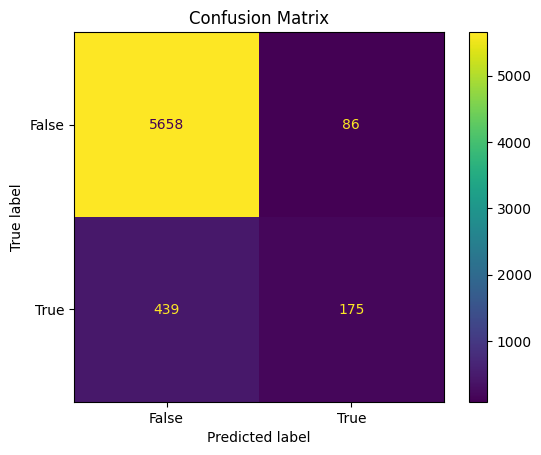

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_valid, y_pred)
plt.title("Confusion Matrix")
plt.show()

### ROC Curve

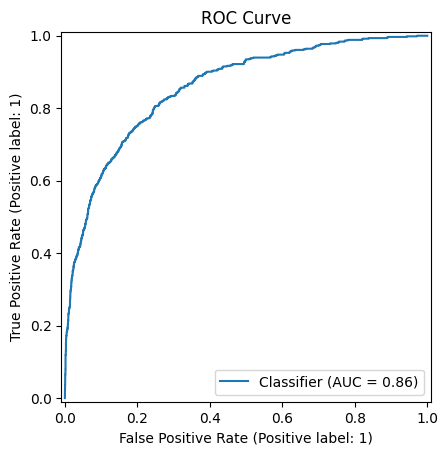

In [30]:
from sklearn.metrics import RocCurveDisplay

y_proba = cbc_2.predict_proba(X_valid)[:, 1]

RocCurveDisplay.from_predictions(y_valid, y_proba)
plt.title("ROC Curve")
plt.show()

### Precision-Recall Curve

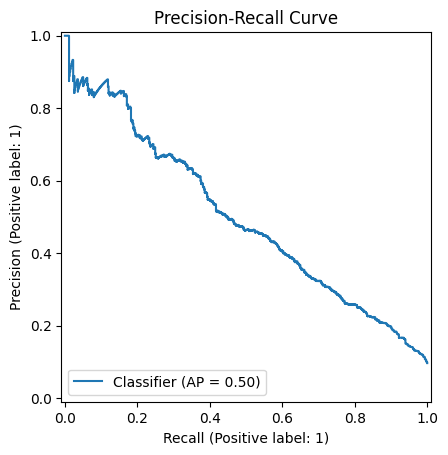

In [31]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_valid, y_proba)
plt.title("Precision-Recall Curve")
plt.show()

### Feature importance

               Feature  Importance
6         WildlifeSize   22.535812
8      WildlifeSpecies   21.685921
0          AirportName   12.991333
5          FlightPhase    9.096302
9             Altitude    8.442217
1   NumberStruckActual    8.290334
3                 Year    5.129124
2                Month    4.199519
10    IsAircraftLarge?    3.621136
4              Engines    2.964248
7        ConditionsSky    1.044054


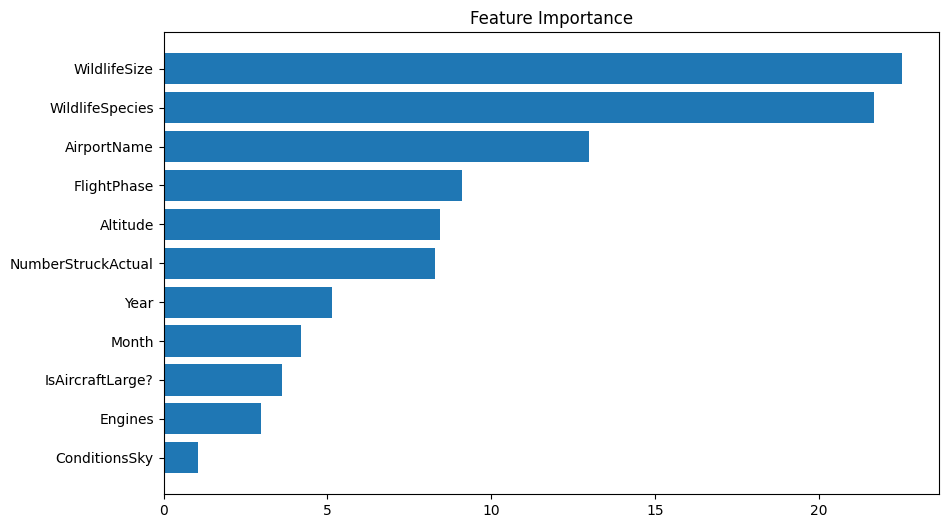

In [34]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": cbc_2.get_feature_importance()
}).sort_values(by="Importance", ascending=False)

print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()